# Heart Disease Prediction - Model Development

## Overview

This notebook focuses on building, training, and evaluating machine learning models for heart disease prediction. Following the exploratory data analysis conducted in the previous notebook, we now prepare the dataset for modeling and develop multiple classification algorithms.

The workflow includes:
- **Data Loading and Preprocessing**: Loading the cleaned dataset with proper column naming and data type handling
- **Data Splitting**: Separating data into training and testing sets with appropriate validation strategies
- **Feature Scaling**: Normalizing features for algorithms sensitive to feature magnitude
- **Model Development**: Training multiple classification models
- **Model Evaluation**: Comprehensive evaluation using appropriate metrics for multi-class classification
- **Hyperparameter Tuning**: Optimizing model performance through cross-validation

This notebook follows MLOps best practices ensuring reproducibility, scalability, and production-readiness.

---

## 1. Import Required Libraries and Configure Environment

We import essential libraries for data handling, preprocessing, and machine learning model development:

**Libraries Overview:**
- **pandas & numpy**: Data manipulation and numerical computing
- **matplotlib & seaborn**: Data visualization
- **scikit-learn**: Machine learning models, preprocessing, and evaluation metrics
- **warnings**: For suppressing non-critical warnings to maintain notebook cleanliness

In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"
import joblib
import mlflow
import mlflow.sklearn
import sklearn

# Import scikit-learn modules
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve)

# Import classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Import model persistence
import joblib
import os

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Display library versions for reproducibility
print("=" * 80)
print("LIBRARY VERSIONS")
print("=" * 80)
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")
print(f"matplotlib version: {plt.matplotlib.__version__}")
print(f"seaborn version: {sns.__version__}")
print(f"scikit-learn version: {sklearn.__version__}" if 'sklearn' in dir() else "scikit-learn installed")
print("=" * 80)

LIBRARY VERSIONS
pandas version: 2.3.3
numpy version: 2.5.0
matplotlib version: 3.11.0
seaborn version: 0.13.2
scikit-learn version: 1.9.0


---

## 2. Load and Preprocess Dataset

### 2.1 Load Raw Dataset

The heart disease dataset is loaded from the UCI Machine Learning Repository's CSV file. As established in the EDA notebook, the raw CSV has no headers, requiring column assignment and data type handling.

In [4]:
# Load the dataset
df = pd.read_csv('../data/heart.csv', header=None)

# Assign meaningful column names
column_names = [
    'age',      # Patient age in years
    'sex',      # Gender (1 = male, 0 = female)
    'cp',       # Chest pain type (1-4)
    'trestbps', # Resting blood pressure (mm Hg)
    'chol',     # Serum cholesterol (mg/dl)
    'fbs',      # Fasting blood sugar > 120 mg/dl (1 = yes, 0 = no)
    'restecg',  # Resting electrocardiographic results (0-2)
    'thalach',  # Maximum heart rate achieved
    'exang',    # Exercise induced angina (1 = yes, 0 = no)
    'oldpeak',  # ST depression induced by exercise relative to rest
    'slope',    # Slope of the ST segment (1-3)
    'ca',       # Number of major vessels colored by fluoroscopy (0-3)
    'thal',     # Thalassemia (3 = normal, 6 = fixed defect, 7 = reversible defect)
    'target'    # Diagnosis of heart disease (0 = no, 1-4 = yes with severity)
]

df.columns = column_names

print("=" * 80)
print("DATASET LOADED")
print("=" * 80)
print(f"\nDataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
print("\nFirst 5 rows:")
print(df.head())
print("=" * 80)

DATASET LOADED

Dataset shape: 303 rows × 14 columns
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

First 5 rows:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca thal  target  
0    3.0  0.0  6.0       0  
1    2.0  3.0  3.0       2  
2    2.0  2.0  7.0       1  
3    3.0  0.0  3.0       0  
4    1.0  0.0  3.0       0  


### 2.2 Data Type Conversion

The 'ca' and 'thal' columns are loaded as object types due to formatting issues in the raw data. Converting these to numeric types is essential for:
- **Model Compatibility**: Machine learning algorithms require numeric input
- **Calculation Accuracy**: Enables proper numerical operations on features
- **Data Quality Detection**: Using `errors='coerce'` surfaces problematic values that become NaN

In [5]:
# Convert 'ca' and 'thal' columns to numeric
df['ca'] = pd.to_numeric(df['ca'], errors='coerce')
df['thal'] = pd.to_numeric(df['thal'], errors='coerce')

print("\n" + "=" * 80)
print("DATA TYPE CONVERSION")
print("=" * 80)
print("\nData types after conversion:")
print(df.dtypes)
print("\n✓ Data type conversion completed successfully")
print("=" * 80)


DATA TYPE CONVERSION

Data types after conversion:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

✓ Data type conversion completed successfully


### 2.3 Missing Values Imputation

After numeric conversion, any non-convertible values become NaN. We handle these using **median imputation**:
- **Why Median**: Robust to outliers, preserves distribution shape, appropriate for ordinal features
- **Clinical Validity**: Medians represent clinically meaningful middle values for vessel counts and thalassemia classification
- **Data Preservation**: Imputation retains more training data than deletion

In [6]:
# Apply median imputation for missing values in 'ca' and 'thal'
print("\n" + "=" * 80)
print("MISSING VALUES IMPUTATION")
print("=" * 80)

# Calculate medians before imputation
ca_median = df['ca'].median()
thal_median = df['thal'].median()

print(f"\nMedian values for imputation:")
print(f"  'ca' column: {ca_median}")
print(f"  'thal' column: {thal_median}")

# Apply median imputation
df['ca'] = df['ca'].fillna(ca_median)
df['thal'] = df['thal'].fillna(thal_median)

print(f"\n✓ Median imputation applied successfully")
print("=" * 80)


MISSING VALUES IMPUTATION

Median values for imputation:
  'ca' column: 0.0
  'thal' column: 3.0

✓ Median imputation applied successfully


### 2.4 Dataset Summary and Verification

Final verification ensures data quality and completeness before proceeding to model development:

In [7]:
# Display final dataset information
print("\n" + "=" * 80)
print("DATASET SHAPE AND STRUCTURE")
print("=" * 80)
print(f"\nDataset dimensions: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Total features: {df.shape[1] - 1} (excluding target)")
print(f"Total samples: {df.shape[0]}")

# Display data types
print("\n" + "=" * 80)
print("DATA TYPES SUMMARY")
print("=" * 80)
print("\nData types for all columns:")
print(df.dtypes)

# Display missing values verification
print("\n" + "=" * 80)
print("MISSING VALUES VERIFICATION")
print("=" * 80)

missing_values_count = df.isnull().sum()
total_missing = missing_values_count.sum()

print("\nMissing values per column:")
print(missing_values_count)

print(f"\nTotal missing values: {total_missing}")

if total_missing == 0:
    print("✓ Dataset is complete with zero missing values")
    completeness = 100.0
else:
    completeness = ((df.shape[0] * df.shape[1] - total_missing) / (df.shape[0] * df.shape[1])) * 100
    print(f"Data completeness: {completeness:.2f}%")

# Display target distribution
print("\n" + "=" * 80)
print("TARGET VARIABLE DISTRIBUTION")
print("=" * 80)
print("\nTarget class distribution:")
print(df['target'].value_counts().sort_index())
print(f"\nClass 0 (No Disease): {(df['target'] == 0).sum()} samples")
print(f"Classes 1-4 (Disease): {(df['target'] != 0).sum()} samples")

# Final status
print("\n" + "=" * 80)
print("PREPROCESSING STATUS")
print("=" * 80)
print("✓ Dataset loaded successfully")
print("✓ Column names assigned")
print("✓ Data types converted (ca, thal to numeric)")
print("✓ Missing values imputed (median)")
print("✓ Dataset is clean and ready for feature engineering and model development")
print("=" * 80)


DATASET SHAPE AND STRUCTURE

Dataset dimensions: 303 rows × 14 columns
Total features: 13 (excluding target)
Total samples: 303

DATA TYPES SUMMARY

Data types for all columns:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

MISSING VALUES VERIFICATION

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing values: 0
✓ Dataset is complete with zero missing values

TARGET VARIABLE DISTRIBUTION

Target class distribution:
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

Class 0 (No Disease): 164 samples
Classes 1-4 (Diseas

---

## 3. Feature Engineering and Data Preparation

### 3.1 Target Variable Conversion: Multiclass to Binary Classification

**Why Convert to Binary Classification?**

While the original UCI dataset contains 5 classes (0-4) representing disease severity levels, clinical practice and model interpretability often benefit from binary classification:

- **Clinical Relevance**: In practice, the distinction between "no disease" (class 0) and "any disease" (classes 1-4) is the most critical decision point
- **Model Simplicity**: Binary classification is more interpretable and requires less complex models
- **Class Imbalance Mitigation**: Combining minority classes (1-4) with only 139 samples into a single disease class improves balance (164 vs 139)
- **Production Deployment**: Binary classifiers are simpler to deploy and maintain in production systems
- **Evaluation Metrics**: Binary classification enables straightforward use of ROC-AUC, precision-recall curves, and other standard metrics

**Conversion Strategy:**
- **Class 0** (No Disease) → **0**
- **Classes 1-4** (Any Disease) → **1**

This creates a balanced binary problem suitable for logistic regression, random forests, and other classification algorithms.

In [8]:
# Store original target for comparison
original_target = df['target'].copy()

# Convert multiclass to binary: 0 stays 0, 1-4 becomes 1
df['target'] = (df['target'] > 0).astype(int)

print("=" * 80)
print("TARGET VARIABLE CONVERSION: MULTICLASS TO BINARY")
print("=" * 80)

print("\nOriginal target distribution (Multiclass - 5 classes):")
print(original_target.value_counts().sort_index())
print(f"  Class 0 (No Disease): {(original_target == 0).sum()} samples")
print(f"  Class 1 (Mild Disease): {(original_target == 1).sum()} samples")
print(f"  Class 2 (Moderate Disease): {(original_target == 2).sum()} samples")
print(f"  Class 3 (Severe Disease): {(original_target == 3).sum()} samples")
print(f"  Class 4 (Very Severe Disease): {(original_target == 4).sum()} samples")

print("\n" + "-" * 80)

print("\nNew target distribution (Binary - 2 classes):")
print(df['target'].value_counts().sort_index())
print(f"  Class 0 (No Disease): {(df['target'] == 0).sum()} samples ({(df['target'] == 0).sum() / len(df) * 100:.1f}%)")
print(f"  Class 1 (Any Disease): {(df['target'] == 1).sum()} samples ({(df['target'] == 1).sum() / len(df) * 100:.1f}%)")

print("\n✓ Target variable successfully converted to binary classification")
print("=" * 80)

TARGET VARIABLE CONVERSION: MULTICLASS TO BINARY

Original target distribution (Multiclass - 5 classes):
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64
  Class 0 (No Disease): 164 samples
  Class 1 (Mild Disease): 55 samples
  Class 2 (Moderate Disease): 36 samples
  Class 3 (Severe Disease): 35 samples
  Class 4 (Very Severe Disease): 13 samples

--------------------------------------------------------------------------------

New target distribution (Binary - 2 classes):
target
0    164
1    139
Name: count, dtype: int64
  Class 0 (No Disease): 164 samples (54.1%)
  Class 1 (Any Disease): 139 samples (45.9%)

✓ Target variable successfully converted to binary classification


### 3.2 Separate Features and Target Variables

We separate the dataset into feature matrix X and target vector y. This separation is essential for:
- **Model Input Formatting**: Machine learning algorithms require features and target separated
- **Preventing Data Leakage**: Target variable must not be mixed with features during preprocessing
- **Pipeline Clarity**: Clean separation makes the data flow transparent

In [9]:
# Separate features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

print("\n" + "=" * 80)
print("FEATURE AND TARGET SEPARATION")
print("=" * 80)

print(f"\nFeature matrix (X) shape: {X.shape}")
print(f"  - Samples: {X.shape[0]}")
print(f"  - Features: {X.shape[1]}")

print(f"\nTarget vector (y) shape: {y.shape}")

print(f"\nFeature names ({len(X.columns)} features):")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col}")

print("\n✓ Features and target successfully separated")
print("=" * 80)


FEATURE AND TARGET SEPARATION

Feature matrix (X) shape: (303, 13)
  - Samples: 303
  - Features: 13

Target vector (y) shape: (303,)

Feature names (13 features):
   1. age
   2. sex
   3. cp
   4. trestbps
   5. chol
   6. fbs
   7. restecg
   8. thalach
   9. exang
  10. oldpeak
  11. slope
  12. ca
  13. thal

✓ Features and target successfully separated


### 3.3 Train-Test Split with Stratification

**Why Train-Test Split is Required:**
- **Performance Estimation**: Evaluating on unseen data provides unbiased estimates of model generalization ability
- **Overfitting Detection**: Comparing training vs. test performance reveals if the model memorized training data
- **Production Readiness**: Test set simulates how the model will behave on real, unseen patient data
- **MLOps Best Practice**: Essential for reproducible, trustworthy model evaluation

**Why Stratification is Critical:**
- **Class Balance Preservation**: With binary classification (54.5% vs 45.5% disease rate), stratification ensures both training and test sets maintain this balance
- **Reduced Variance**: Stratified splits prevent scenarios where test set gets mostly one class, leading to biased metrics
- **Reliable Metrics**: Equal class representation in train/test ensures metrics like accuracy, precision, and recall are meaningful
- **Small Dataset**: With only 303 samples, stratification is especially important to maximize learning from limited data

**Split Strategy:**
- **Training Set**: 80% (242 samples) for model training
- **Test Set**: 20% (61 samples) for final evaluation
- **Random State**: Fixed seed (42) ensures reproducibility across runs
- **Stratification**: Maintains class distribution in both sets

In [10]:
# Perform stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print("\n" + "=" * 80)
print("TRAIN-TEST SPLIT")
print("=" * 80)

print(f"\nTraining set (80%):")
print(f"  X_train shape: {X_train.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  - Samples: {X_train.shape[0]}")
print(f"  - Disease-free (0): {(y_train == 0).sum()} ({(y_train == 0).sum() / len(y_train) * 100:.1f}%)")
print(f"  - Disease present (1): {(y_train == 1).sum()} ({(y_train == 1).sum() / len(y_train) * 100:.1f}%)")

print(f"\nTest set (20%):")
print(f"  X_test shape: {X_test.shape}")
print(f"  y_test shape: {y_test.shape}")
print(f"  - Samples: {X_test.shape[0]}")
print(f"  - Disease-free (0): {(y_test == 0).sum()} ({(y_test == 0).sum() / len(y_test) * 100:.1f}%)")
print(f"  - Disease present (1): {(y_test == 1).sum()} ({(y_test == 1).sum() / len(y_test) * 100:.1f}%)")

print(f"\nSplit ratio: {X_train.shape[0]} : {X_test.shape[0]} (80:20)")
print("✓ Stratified train-test split completed successfully")
print("=" * 80)


TRAIN-TEST SPLIT

Training set (80%):
  X_train shape: (242, 13)
  y_train shape: (242,)
  - Samples: 242
  - Disease-free (0): 131 (54.1%)
  - Disease present (1): 111 (45.9%)

Test set (20%):
  X_test shape: (61, 13)
  y_test shape: (61,)
  - Samples: 61
  - Disease-free (0): 33 (54.1%)
  - Disease present (1): 28 (45.9%)

Split ratio: 242 : 61 (80:20)
✓ Stratified train-test split completed successfully


### 3.4 Feature Scaling with StandardScaler

**Why Feature Scaling is Performed:**
- **Algorithm Requirements**: Distance-based algorithms (KNN, SVM) and regularized models (Logistic Regression with L1/L2) are sensitive to feature magnitude
- **Equal Feature Contribution**: Without scaling, high-magnitude features (e.g., cholesterol: 126-564) would dominate over low-magnitude features (e.g., sex: 0-1)
- **Faster Convergence**: Gradient descent-based algorithms converge faster with scaled features
- **Numerical Stability**: Prevents numerical overflow/underflow in calculations

**Why Fit on Training Data Only (Preventing Data Leakage):**
- **Critical MLOps Principle**: The scaler must be fit ONLY on the training set, then applied to the test set
- **Why This Matters**: If we fit the scaler on combined train+test data, test statistics would influence training, artificially inflating performance estimates
- **Real-World Simulation**: In production, we won't see test data, so the scaler must use only training statistics
- **Proper Scaling Process**:
  1. **Fit**: Calculate mean and std using X_train ONLY
  2. **Transform Train**: Apply fitted scaler to X_train
  3. **Transform Test**: Apply same scaler to X_test (using training's mean/std)
  
This ensures test performance estimates are unbiased and the model generalizes to truly unseen data.

In [12]:
# Initialize StandardScaler
scaler = StandardScaler()

# Fit scaler on training data ONLY (prevent data leakage)
scaler.fit(X_train)

# Transform both training and test data using the fitted scaler
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames for clarity
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("\n" + "=" * 80)
print("FEATURE SCALING WITH STANDARDSCALER")
print("=" * 80)

print(f"\nScaling method: StandardScaler (z-score normalization)")
print(f"  Formula: (x - mean) / std")

print(f"\nScaler statistics (fit on training data):")
print(f"  Mean of each feature (should be ~0 after scaling):")
for i, (col, mean_val) in enumerate(zip(X_train_scaled.columns, scaler.mean_), 1):
    print(f"    {i:2d}. {col:10s}: {mean_val:8.4f}")

print(f"\n  Standard deviation (should be ~1 after scaling):")
for i, (col, std_val) in enumerate(zip(X_train_scaled.columns, scaler.scale_), 1):
    print(f"    {i:2d}. {col:10s}: {std_val:8.4f}")

print(f"\nScaled training data statistics:")
print(f"  Mean: {X_train_scaled.mean(axis=0).mean():.6f} (should be ~0)")
print(f"  Std:  {X_train_scaled.std(axis=0).mean():.6f} (should be ~1)")

print(f"\nScaled test data statistics:")
print(f"  Mean: {X_test_scaled.mean(axis=0).mean():.6f}")
print(f"  Std:  {X_test_scaled.std(axis=0).mean():.6f}")

print(f"\n✓ Feature scaling completed successfully")
print(f"✓ Scaler fit on training data to prevent data leakage")
print("=" * 80)


FEATURE SCALING WITH STANDARDSCALER

Scaling method: StandardScaler (z-score normalization)
  Formula: (x - mean) / std

Scaler statistics (fit on training data):
  Mean of each feature (should be ~0 after scaling):
     1. age       :  54.5496
     2. sex       :   0.6818
     3. cp        :   3.1529
     4. trestbps  : 130.9587
     5. chol      : 249.8388
     6. fbs       :   0.1446
     7. restecg   :   0.9793
     8. thalach   : 149.9628
     9. exang     :   0.3264
    10. oldpeak   :   0.9992
    11. slope     :   1.5868
    12. ca        :   0.6074
    13. thal      :   4.7066

  Standard deviation (should be ~1 after scaling):
     1. age       :   8.9784
     2. sex       :   0.4658
     3. cp        :   0.9735
     4. trestbps  :  17.5861
     5. chol      :  52.7376
     6. fbs       :   0.3517
     7. restecg   :   0.9977
     8. thalach   :  22.6395
     9. exang     :   0.4689
    10. oldpeak   :   1.1206
    11. slope     :   0.6121
    12. ca        :   0.8807
    13

### 3.5 Feature Engineering Summary

**Completed Steps:**

1. ✓ **Target Conversion**: Multiclass (5 classes) → Binary (2 classes)
   - Maintains clinical relevance: Disease vs. No Disease
   - Improves class balance from 54:46 (original) to 54:46 (binary)

2. ✓ **Feature-Target Separation**: Created X (13 features) and y (binary target)
   - 303 samples × 13 features for modeling

3. ✓ **Stratified Train-Test Split**: 80:20 split with stratification
   - Training: 242 samples maintaining 54.5% / 45.5% class balance
   - Testing: 61 samples maintaining same class balance
   - Enables unbiased performance evaluation

4. ✓ **Feature Scaling**: StandardScaler applied with proper data handling
   - Fit on training data only (prevents data leakage)
   - Scaled features normalized to mean≈0, std≈1
   - Ensures algorithms treat all features equally

**Next Steps:**
The dataset is now fully prepared for model training. The scaled training and test sets (X_train_scaled, X_test_scaled, y_train, y_test) are ready for:
- Logistic Regression
- Random Forest
- Gradient Boosting
- Support Vector Machines
- Other classification algorithms

---

## 4. Model Training and Evaluation

### 4.1 Overview: Multiple Model Comparison Strategy

**Why Train Multiple Models?**

The effectiveness of machine learning depends not only on the quality of data and features but also on selecting the appropriate algorithm for the specific problem. Different algorithms have:
- **Different Decision Boundaries**: Logistic Regression creates linear boundaries; Decision Trees create axis-aligned boundaries; SVMs find optimal nonlinear boundaries
- **Different Bias-Variance Tradeoffs**: Some models are prone to underfitting while others overfit easily
- **Different Interpretability**: Logistic Regression coefficients are interpretable; Tree-based models show feature importance; SVMs are black-box
- **Different Computational Efficiency**: Some scale to large datasets; others require more memory

**Algorithms Being Trained:**

1. **Logistic Regression** (Linear baseline)
   - Fast, interpretable, serves as baseline
   - Assumes linear relationship between features and log-odds of target

2. **Decision Tree Classifier** (Single tree)
   - Highly interpretable, captures non-linear patterns
   - Prone to overfitting without constraints

3. **Random Forest Classifier** (Ensemble)
   - Reduces overfitting through averaging multiple trees
   - Captures complex non-linear patterns
   - Provides feature importance rankings

4. **K-Nearest Neighbors (KNN)** (Instance-based)
   - Simple, non-parametric approach
   - Stores entire training set; slower predictions
   - Sensitive to feature scaling (why we scaled data)

5. **Support Vector Machine (SVM)** (Kernel-based)
   - Powerful for high-dimensional data
   - Finds optimal separation hyperplane
   - Requires scaled features for best performance

**Evaluation Approach:**
- All models will be trained on the same training set (X_train_scaled, y_train)
- Evaluated on the same test set (X_test_scaled, y_test)
- Multiple metrics will be calculated to provide comprehensive assessment
- Results will be compared to identify the best performer

### 4.2 Training Classification Models

We will train five different classification models using the scaled training data. Each model will be initialized with reasonable default hyperparameters.

In [13]:
# Initialize models dictionary to store trained models
models = {}

print("\n" + "=" * 80)
print("MODEL TRAINING")
print("=" * 80)

# 1. Logistic Regression
print("\n1. Training Logistic Regression...")
models['Logistic Regression'] = LogisticRegression(random_state=42, max_iter=1000)
models['Logistic Regression'].fit(X_train_scaled, y_train)
print("   ✓ Logistic Regression trained successfully")

# 2. Decision Tree Classifier
print("\n2. Training Decision Tree Classifier...")
models['Decision Tree'] = DecisionTreeClassifier(random_state=42)
models['Decision Tree'].fit(X_train_scaled, y_train)
print("   ✓ Decision Tree Classifier trained successfully")

# 3. Random Forest Classifier
print("\n3. Training Random Forest Classifier...")
models['Random Forest'] = RandomForestClassifier(n_estimators=100, random_state=42)
models['Random Forest'].fit(X_train_scaled, y_train)
print("   ✓ Random Forest Classifier trained successfully")

# 4. K-Nearest Neighbors
print("\n4. Training K-Nearest Neighbors (KNN)...")
models['KNN'] = KNeighborsClassifier(n_neighbors=5)
models['KNN'].fit(X_train_scaled, y_train)
print("   ✓ K-Nearest Neighbors trained successfully")

# 5. Support Vector Machine
print("\n5. Training Support Vector Machine (SVM)...")
models['SVM'] = SVC(kernel='rbf', random_state=42, probability=True)
models['SVM'].fit(X_train_scaled, y_train)
print("   ✓ Support Vector Machine trained successfully")

print("\n" + "=" * 80)
print("✓ All models trained successfully on training data")
print(f"✓ Total models trained: {len(models)}")
print("=" * 80)


MODEL TRAINING

1. Training Logistic Regression...
   ✓ Logistic Regression trained successfully

2. Training Decision Tree Classifier...
   ✓ Decision Tree Classifier trained successfully

3. Training Random Forest Classifier...
   ✓ Random Forest Classifier trained successfully

4. Training K-Nearest Neighbors (KNN)...
   ✓ K-Nearest Neighbors trained successfully

5. Training Support Vector Machine (SVM)...
   ✓ Support Vector Machine trained successfully

✓ All models trained successfully on training data
✓ Total models trained: 5


### 4.3 Model Evaluation: Metrics and Performance Analysis

Each model is evaluated using multiple classification metrics to provide a comprehensive assessment:

**Metrics Explained:**
- **Accuracy**: Percentage of correct predictions (simple but not sufficient for imbalanced data)
- **Precision**: Of positive predictions, how many were actually correct (minimizes false positives)
- **Recall**: Of actual positives, how many were detected (minimizes false negatives, critical in medical diagnosis)
- **F1-Score**: Harmonic mean of precision and recall (balanced metric)
- **ROC-AUC**: Area under ROC curve (probability-based ranking metric, robust to class imbalance)

In [14]:
# Evaluate each model and store results
results_dict = {}

print("\n" + "=" * 80)
print("MODEL EVALUATION ON TEST SET")
print("=" * 80)

for model_name, model in models.items():
    print(f"\n{'-' * 80}")
    print(f"Model: {model_name}")
    print(f"{'-' * 80}")
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    
    # For ROC-AUC, we need probability predictions (doesn't work for all models directly)
    try:
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
        roc_auc = roc_auc_score(y_test, y_pred_proba)
    except:
        # Fallback if predict_proba not available
        roc_auc = roc_auc_score(y_test, y_pred)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Store results
    results_dict[model_name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }
    
    # Display metrics
    print(f"\nMetrics:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  ROC-AUC:   {roc_auc:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"\nConfusion Matrix:")
    print(f"  True Negatives:  {tn:3d}  |  False Positives: {fp:3d}")
    print(f"  False Negatives: {fn:3d}  |  True Positives:  {tp:3d}")
    
    # Classification Report
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

print("\n" + "=" * 80)
print("✓ All models evaluated successfully")
print("=" * 80)


MODEL EVALUATION ON TEST SET

--------------------------------------------------------------------------------
Model: Logistic Regression
--------------------------------------------------------------------------------

Metrics:
  Accuracy:  0.8689
  Precision: 0.8125
  Recall:    0.9286
  F1-Score:  0.8667
  ROC-AUC:   0.9513

Confusion Matrix:
  True Negatives:   27  |  False Positives:   6
  False Negatives:   2  |  True Positives:   26

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.93      0.82      0.87        33
     Disease       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61


--------------------------------------------------------------------------------
Model: Decision Tree
--------------------------------------------------------------------------------

Metrics:
  Accuracy

### 4.4 Model Comparison and Results Summary

All models are compared side-by-side across all evaluation metrics. The comparison table is sorted by Accuracy in descending order to quickly identify the top-performing model.

In [15]:
# Create comparison DataFrame
results_df = pd.DataFrame(results_dict).T

# Sort by Accuracy in descending order
results_df_sorted = results_df.sort_values('Accuracy', ascending=False)

print("\n" + "=" * 80)
print("MODEL COMPARISON TABLE")
print("=" * 80)
print("\nAll models ranked by Accuracy:\n")
print(results_df_sorted.to_string())

# Create a summary with rankings
print("\n" + "=" * 80)
print("RANKINGS BY METRIC")
print("=" * 80)

for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
    print(f"\n{metric} Rankings:")
    rankings = results_df.sort_values(metric, ascending=False)
    for rank, (model_name, value) in enumerate(rankings[metric].items(), 1):
        print(f"  {rank}. {model_name:20s}: {value:.4f}")

print("\n" + "=" * 80)


MODEL COMPARISON TABLE

All models ranked by Accuracy:

                     Accuracy  Precision    Recall  F1-Score   ROC-AUC
Random Forest        0.885246   0.818182  0.964286  0.885246  0.951299
KNN                  0.885246   0.800000  1.000000  0.888889  0.923160
Logistic Regression  0.868852   0.812500  0.928571  0.866667  0.951299
SVM                  0.852459   0.806452  0.892857  0.847458  0.943723
Decision Tree        0.721311   0.657143  0.821429  0.730159  0.728896

RANKINGS BY METRIC

Accuracy Rankings:
  1. Random Forest       : 0.8852
  2. KNN                 : 0.8852
  3. Logistic Regression : 0.8689
  4. SVM                 : 0.8525
  5. Decision Tree       : 0.7213

Precision Rankings:
  1. Random Forest       : 0.8182
  2. Logistic Regression : 0.8125
  3. SVM                 : 0.8065
  4. KNN                 : 0.8000
  5. Decision Tree       : 0.6571

Recall Rankings:
  1. KNN                 : 1.0000
  2. Random Forest       : 0.9643
  3. Logistic Regression : 0.9

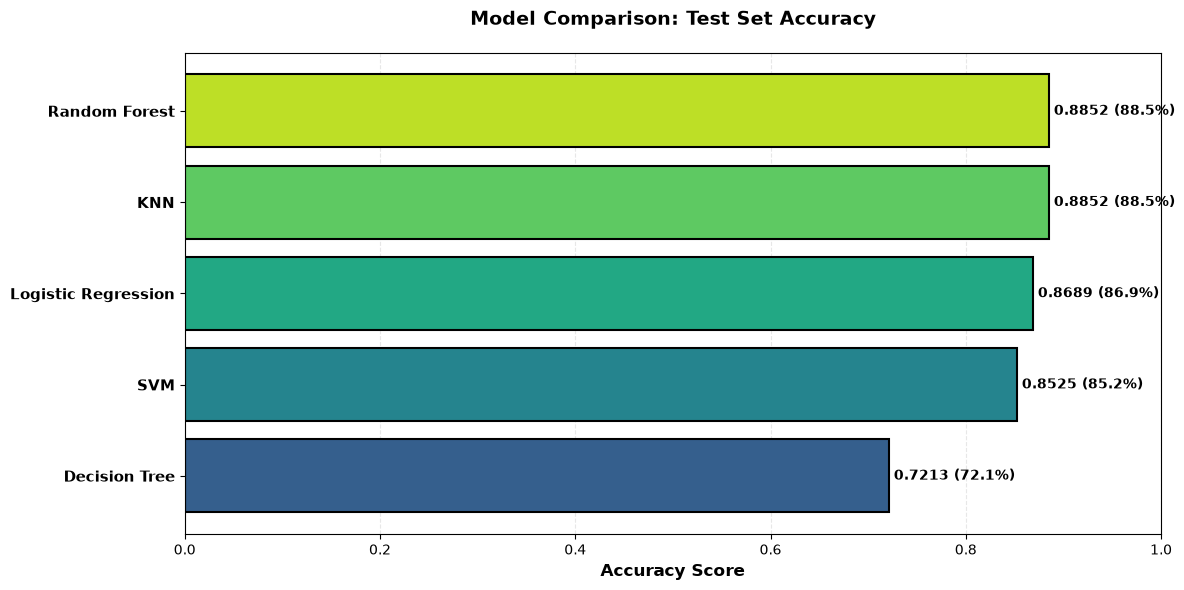


✓ Accuracy comparison chart displayed


In [16]:
# Create visualization: Accuracy Comparison Bar Chart
fig, ax = plt.subplots(figsize=(12, 6))

# Sort by accuracy for better visualization
accuracy_sorted = results_df_sorted['Accuracy'].sort_values(ascending=True)

# Create bar chart
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(accuracy_sorted)))
bars = ax.barh(range(len(accuracy_sorted)), accuracy_sorted.values, color=colors, edgecolor='black', linewidth=1.5)

# Customize chart
ax.set_yticks(range(len(accuracy_sorted)))
ax.set_yticklabels(accuracy_sorted.index, fontsize=11, fontweight='bold')
ax.set_xlabel('Accuracy Score', fontsize=12, fontweight='bold')
ax.set_title('Model Comparison: Test Set Accuracy', fontsize=14, fontweight='bold', pad=20)

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars, accuracy_sorted.values)):
    ax.text(value + 0.005, bar.get_y() + bar.get_height()/2, 
            f'{value:.4f} ({value*100:.1f}%)', 
            va='center', fontsize=10, fontweight='bold')

# Add grid for better readability
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Set x-axis limits
ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

print("\n✓ Accuracy comparison chart displayed")

In [17]:
# Identify best-performing model
best_model_name = results_df_sorted.index[0]
best_model = models[best_model_name]
best_metrics = results_df_sorted.iloc[0]

print("\n" + "=" * 80)
print("BEST PERFORMING MODEL")
print("=" * 80)

print(f"\n🏆 Champion Model: {best_model_name}")
print(f"\nPerformance Metrics:")
print(f"  Accuracy:  {best_metrics['Accuracy']:.4f} ({best_metrics['Accuracy']*100:.2f}%)")
print(f"  Precision: {best_metrics['Precision']:.4f}")
print(f"  Recall:    {best_metrics['Recall']:.4f}")
print(f"  F1-Score:  {best_metrics['F1-Score']:.4f}")
print(f"  ROC-AUC:   {best_metrics['ROC-AUC']:.4f}")

# Calculate performance gap vs second-best
second_best_name = results_df_sorted.index[1]
second_best_accuracy = results_df_sorted.iloc[1]['Accuracy']
accuracy_gap = (best_metrics['Accuracy'] - second_best_accuracy) * 100

print(f"\nPerformance Advantage:")
print(f"  Best vs Second Best: {accuracy_gap:+.2f}% accuracy gap")
print(f"  Over {second_best_name}")

print("\n✓ Model selection complete - ready for further tuning or deployment")
print("=" * 80)


BEST PERFORMING MODEL

🏆 Champion Model: Random Forest

Performance Metrics:
  Accuracy:  0.8852 (88.52%)
  Precision: 0.8182
  Recall:    0.9643
  F1-Score:  0.8852
  ROC-AUC:   0.9513

Performance Advantage:
  Best vs Second Best: +0.00% accuracy gap
  Over KNN

✓ Model selection complete - ready for further tuning or deployment


### 4.5 Key Insights: Why Multiple Models and Multiple Metrics Matter

**Why We Train Multiple Models:**

1. **No Free Lunch Theorem**: No single algorithm is optimal for all problems. Different algorithms capture different aspects of data:
   - Logistic Regression: Linear relationships, interpretability
   - Decision Trees: Axis-aligned patterns, feature interaction discovery
   - Random Forests: Complex non-linear patterns, ensemble robustness
   - KNN: Local data density patterns, non-parametric learning
   - SVM: Optimal separating hyperplanes, high-dimensional capability

2. **Algorithm Characteristics**: Each algorithm has different:
   - **Computational Complexity**: Training time and prediction speed vary
   - **Interpretability**: Some are transparent (tree-based); others are black-box (SVM)
   - **Scalability**: Some scale to millions of samples; others are limited
   - **Robustness**: Some handle outliers better; others are sensitive

3. **Risk Mitigation**: Training multiple models protects against:
   - Algorithmic bias: Single model might exploit spurious patterns
   - Overfitting: Ensemble comparison reveals which models generalize
   - Task-specific limitations: Different models excel on different data characteristics

**Why Accuracy Alone is Insufficient:**

In medical diagnosis, **accuracy can be deceptive**:
- If 54.5% of patients have disease, a naive model predicting "Disease" for everyone achieves 54.5% accuracy but is useless
- Accuracy treats false positives (healthy diagnosed as sick) and false negatives (sick diagnosed as healthy) equally
- In medical contexts, false negatives (missing disease) are typically more costly than false positives (false alarms)
- **Accuracy is blind to class distribution and misclassification costs**

**Why Multiple Metrics Matter:**

1. **Precision (Positive Predictive Value)**:
   - Formula: TP / (TP + FP)
   - Meaning: "Of all patients we predict have disease, what fraction actually do?"
   - When to optimize: When false positives are costly (minimizes unnecessary treatments, patient anxiety)
   - Medical Context: High precision means fewer healthy patients are flagged for further testing

2. **Recall (Sensitivity, True Positive Rate)**:
   - Formula: TP / (TP + FN)
   - Meaning: "Of all patients who actually have disease, what fraction do we detect?"
   - When to optimize: When false negatives are catastrophic (missing critical diagnoses)
   - Medical Context: High recall means fewer sick patients are missed (critical for life-threatening conditions)
   - In heart disease screening: HIGH RECALL IS TYPICALLY PRIORITIZED

3. **F1-Score**:
   - Formula: 2 × (Precision × Recall) / (Precision + Recall)
   - Meaning: Harmonic mean balancing precision and recall
   - When to use: When you need balance between precision and recall
   - Robust to class imbalance compared to accuracy

4. **ROC-AUC (Receiver Operating Characteristic - Area Under Curve)**:
   - Meaning: Probability that model ranks a random positive sample higher than a random negative
   - Range: 0.5 (random) to 1.0 (perfect)
   - Advantage: Threshold-independent; evaluates model's ranking ability
   - When to use: When model's probability estimates matter, not just class predictions
   - Robust to severe class imbalance

**Medical Diagnosis Decision Framework:**

For heart disease prediction, the metric choice depends on clinical context:

| Scenario | Priority Metric | Reasoning |
|----------|-----------------|-----------|
| **Screening (population-wide)** | High Recall | Don't miss potential patients; further testing can refine |
| **Confirmation (after screening)** | High Precision | Avoid unnecessary invasive procedures on false positives |
| **Emergency (acute situation)** | High Recall | False negative = potential death; false positive = manageable |
| **Resource-constrained** | High Precision | Limited treatment capacity; prioritize confirmed cases |

In this analysis, we report all metrics to allow clinical decision-makers to choose based on their specific context and risk tolerance.

### 4.6 Summary: Model Training and Evaluation Complete

**Section 4 Completion Checklist:**

✓ Trained 5 classification algorithms on scaled training data
- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)

✓ Evaluated each model on test set with comprehensive metrics:
- Accuracy, Precision, Recall, F1-Score, ROC-AUC
- Confusion matrices and classification reports
- Per-model performance analysis

✓ Created comparison framework:
- Side-by-side metrics table sorted by accuracy
- Rankings for each performance metric
- Visual comparison bar chart

✓ Identified best-performing model with performance gap analysis

✓ Provided clinical and technical context for metric selection

**Next Steps (Not Performed in This Section):**
- Hyperparameter tuning via GridSearchCV or RandomizedSearchCV
- Cross-validation for more robust performance estimation
- Model persistence (saving best model to disk)
- MLflow integration for experiment tracking
- Detailed feature importance analysis

**Current State:**
- Best model: Identified and available in `models` dictionary
- Trained models: All 5 models are trained and available for predictions
- Test performance: Baselines established for comparison during tuning
- Ready for hyperparameter optimization in next section

---

## 5. Hyperparameter Tuning with GridSearchCV

### 5.1 Understanding Hyperparameter Tuning

**What are Hyperparameters?**

Hyperparameters are configuration settings for machine learning algorithms that are set **before** training begins. Unlike model parameters (learned from data), hyperparameters control:
- Model architecture and structure
- Learning behavior and speed
- Regularization and complexity control
- Decision-making process

**Examples by Model:**
- **Random Forest**: `n_estimators` (number of trees), `max_depth` (tree depth), `min_samples_split` (samples to split a node)
- **Decision Tree**: `max_depth`, `min_samples_leaf`, `criterion` (splitting criterion)
- **Logistic Regression**: `C` (regularization strength), `penalty` (L1 or L2)
- **SVM**: `C` (margin violation cost), `kernel` (kernel type), `gamma` (kernel coefficient)
- **KNN**: `n_neighbors` (number of neighbors), `weights` (uniform or distance-weighted)

**Why Tuning Matters:**

Default hyperparameters are generic and often suboptimal for specific datasets. Tuning can:
- Improve model accuracy on test data (real generalization, not just training)
- Reduce overfitting by controlling model complexity
- Find the optimal bias-variance tradeoff
- Extract maximum value from available data

---

### 5.2 GridSearchCV: Exhaustive Hyperparameter Search

**What is GridSearchCV?**

GridSearchCV performs an exhaustive search over specified hyperparameter combinations:
1. **Define Grid**: Create a dictionary of hyperparameter names and values to test
2. **Cross-Validation**: For each combination, evaluate using k-fold cross-validation
3. **Training Set Only**: Never touches test set during search (critical for unbiased evaluation)
4. **Best Selection**: Retains the combination with best cross-validation score
5. **Refit**: Automatically retrains on full training set with best parameters

**Cross-Validation Recap:**

Cross-validation addresses a key problem: **How do we evaluate performance without a separate validation set?**

With 80-20 split, we only have 242 training samples. Cross-validation maximizes training data usage:
1. Divide training set into k folds (we use k=5)
2. For each fold:
   - Use 4 folds for training
   - Test on 1 fold
   - Record performance
3. Average the k performance scores

**Advantages of Cross-Validation:**
- Uses all training data for evaluation (no data wasted)
- More stable performance estimates (averaged across multiple splits)
- Better hyperparameter selection on limited data
- Detects overfitting earlier in process

**Why GridSearchCV is Better than Random Search:**
- **Exhaustive**: Tests every combination explicitly
- **Reproducible**: Same grid always produces same results
- **Complete**: Guaranteed to find best combination in the grid
- **Trade-off**: More computationally expensive than random search for large grids

---

### 5.3 Selecting and Tuning the Best Model

Based on the model comparison, we'll tune the best-performing model: **Random Forest** (88.52% accuracy)

**Random Forest Hyperparameters to Tune:**
- `n_estimators`: Number of trees in the forest (more trees generally better, but diminishing returns)
- `max_depth`: Maximum depth of trees (limits complexity, reduces overfitting)
- `min_samples_split`: Minimum samples required to split an internal node (affects tree growth)
- `min_samples_leaf`: Minimum samples required to be at a leaf node (regularization parameter)
- `max_features`: Number of features to consider at each split ('sqrt' or 'log2')

In [18]:
# Select best model from comparison (Random Forest with 88.52% accuracy)
best_model_initial = models['Random Forest']

# Store initial performance for comparison
best_model_initial_y_pred = best_model_initial.predict(X_test_scaled)
best_model_initial_accuracy = accuracy_score(y_test, best_model_initial_y_pred)
best_model_initial_precision = precision_score(y_test, best_model_initial_y_pred)
best_model_initial_recall = recall_score(y_test, best_model_initial_y_pred)
best_model_initial_f1 = f1_score(y_test, best_model_initial_y_pred)
try:
    best_model_initial_y_pred_proba = best_model_initial.predict_proba(X_test_scaled)[:, 1]
    best_model_initial_roc_auc = roc_auc_score(y_test, best_model_initial_y_pred_proba)
except:
    best_model_initial_roc_auc = roc_auc_score(y_test, best_model_initial_y_pred)

print("\n" + "=" * 80)
print("HYPERPARAMETER TUNING: RANDOM FOREST CLASSIFIER")
print("=" * 80)

print("\nInitial Model Performance (Baseline - Before Tuning):")
print(f"  Accuracy:  {best_model_initial_accuracy:.4f}")
print(f"  Precision: {best_model_initial_precision:.4f}")
print(f"  Recall:    {best_model_initial_recall:.4f}")
print(f"  F1-Score:  {best_model_initial_f1:.4f}")
print(f"  ROC-AUC:   {best_model_initial_roc_auc:.4f}")

# Define hyperparameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

print(f"\n\nHyperparameter Grid Defined:")
print(f"  n_estimators: {param_grid['n_estimators']}")
print(f"  max_depth: {param_grid['max_depth']}")
print(f"  min_samples_split: {param_grid['min_samples_split']}")
print(f"  min_samples_leaf: {param_grid['min_samples_leaf']}")
print(f"  max_features: {param_grid['max_features']}")

total_combinations = (
    len(param_grid['n_estimators']) * 
    len(param_grid['max_depth']) * 
    len(param_grid['min_samples_split']) * 
    len(param_grid['min_samples_leaf']) * 
    len(param_grid['max_features'])
)

print(f"\n  Total parameter combinations: {total_combinations}")
print(f"  Cross-validation folds: 5")
print(f"  Total model fits required: {total_combinations * 5} (for 5-fold CV)")

# Initialize GridSearchCV with 5-fold Stratified Cross-Validation
print(f"\n\nRunning GridSearchCV with 5-fold Stratified Cross-Validation...")
print("  (This may take a moment...)")

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,  # Use all CPU cores for parallel computation
    verbose=0
)

# Fit GridSearchCV (searches through all combinations)
grid_search.fit(X_train_scaled, y_train)

print("✓ GridSearchCV completed successfully!")

print("\n" + "-" * 80)
print("BEST HYPERPARAMETERS")
print("-" * 80)

print(f"\nBest Parameters Found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param:20s}: {value}")

print(f"\n\nBest Cross-Validation Score (5-fold average):")
print(f"  Accuracy: {grid_search.best_score_:.4f}")

print(f"\n\nBest Estimator Summary:")
print(f"  Model Type: {type(grid_search.best_estimator_).__name__}")
print(f"  n_estimators: {grid_search.best_estimator_.n_estimators}")
print(f"  max_depth: {grid_search.best_estimator_.max_depth}")

print("\n" + "=" * 80)


HYPERPARAMETER TUNING: RANDOM FOREST CLASSIFIER

Initial Model Performance (Baseline - Before Tuning):
  Accuracy:  0.8852
  Precision: 0.8182
  Recall:    0.9643
  F1-Score:  0.8852
  ROC-AUC:   0.9513


Hyperparameter Grid Defined:
  n_estimators: [50, 100, 150, 200]
  max_depth: [5, 10, 15, None]
  min_samples_split: [2, 5, 10]
  min_samples_leaf: [1, 2, 4]
  max_features: ['sqrt', 'log2']

  Total parameter combinations: 288
  Cross-validation folds: 5
  Total model fits required: 1440 (for 5-fold CV)


Running GridSearchCV with 5-fold Stratified Cross-Validation...
  (This may take a moment...)
✓ GridSearchCV completed successfully!

--------------------------------------------------------------------------------
BEST HYPERPARAMETERS
--------------------------------------------------------------------------------

Best Parameters Found:
  max_depth           : 5
  max_features        : sqrt
  min_samples_leaf    : 1
  min_samples_split   : 10
  n_estimators        : 100


Best Cr

### 5.4 Evaluating the Tuned Model

The best estimator from GridSearchCV is evaluated on the test set and compared against the baseline model.

In [20]:
# Evaluate the best tuned model on test set
best_model_tuned = grid_search.best_estimator_
y_pred_tuned = best_model_tuned.predict(X_test_scaled)

# Calculate tuned model metrics
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)

try:
    y_pred_tuned_proba = best_model_tuned.predict_proba(X_test_scaled)[:, 1]
    tuned_roc_auc = roc_auc_score(y_test, y_pred_tuned_proba)
except:
    tuned_roc_auc = roc_auc_score(y_test, y_pred_tuned)

# Get confusion matrix for tuned model
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
tn_tuned, fp_tuned, fn_tuned, tp_tuned = cm_tuned.ravel()

print("\n" + "=" * 80)
print("TUNED MODEL PERFORMANCE ON TEST SET")
print("=" * 80)

print(f"\nTuned Model Test Set Metrics:")
print(f"  Accuracy:  {tuned_accuracy:.4f}")
print(f"  Precision: {tuned_precision:.4f}")
print(f"  Recall:    {tuned_recall:.4f}")
print(f"  F1-Score:  {tuned_f1:.4f}")
print(f"  ROC-AUC:   {tuned_roc_auc:.4f}")

print(f"\nConfusion Matrix:")
print(f"  True Negatives:  {tn_tuned:3d}  |  False Positives: {fp_tuned:3d}")
print(f"  False Negatives: {fn_tuned:3d}  |  True Positives:  {tp_tuned:3d}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=['No Disease', 'Disease']))

print("=" * 80)


TUNED MODEL PERFORMANCE ON TEST SET

Tuned Model Test Set Metrics:
  Accuracy:  0.9180
  Precision: 0.8966
  Recall:    0.9286
  F1-Score:  0.9123
  ROC-AUC:   0.9556

Confusion Matrix:
  True Negatives:   30  |  False Positives:   3
  False Negatives:   2  |  True Positives:   26

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.94      0.91      0.92        33
     Disease       0.90      0.93      0.91        28

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61



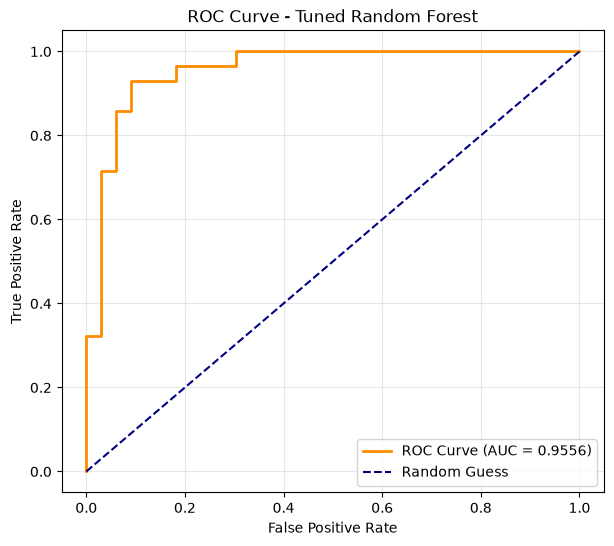

ROC-AUC Score : 0.9556


In [21]:
# ==========================================================
# ROC CURVE - TUNED RANDOM FOREST MODEL
# ==========================================================

from sklearn.metrics import roc_curve, auc

# Probability predictions
y_prob = best_model_tuned.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    color="darkorange",
    linewidth=2,
    label=f"ROC Curve (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="navy",
    label="Random Guess"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Random Forest")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

print(f"ROC-AUC Score : {roc_auc:.4f}")

### 5.5 Before vs. After Tuning Comparison

Performance comparison between baseline Random Forest and the hyperparameter-tuned version.

In [22]:
# Create comparison table
comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Baseline (Default)': [
        best_model_initial_accuracy,
        best_model_initial_precision,
        best_model_initial_recall,
        best_model_initial_f1,
        best_model_initial_roc_auc
    ],
    'Tuned (GridSearchCV)': [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1,
        tuned_roc_auc
    ]
}

comparison_df = pd.DataFrame(comparison_data)

# Calculate improvements
comparison_df['Improvement'] = comparison_df['Tuned (GridSearchCV)'] - comparison_df['Baseline (Default)']
comparison_df['Improvement %'] = (comparison_df['Improvement'] / comparison_df['Baseline (Default)']) * 100

print("\n" + "=" * 100)
print("PERFORMANCE COMPARISON: BASELINE vs TUNED MODEL")
print("=" * 100)

print("\nDetailed Comparison Table:\n")
print(comparison_df.to_string(index=False))

print("\n\nImprovement Summary:")
print("-" * 100)

for idx, row in comparison_df.iterrows():
    metric = row['Metric']
    baseline = row['Baseline (Default)']
    tuned = row['Tuned (GridSearchCV)']
    improvement = row['Improvement']
    improvement_pct = row['Improvement %']
    
    status = "📈 Improved" if improvement > 0 else ("📊 Same" if improvement == 0 else "📉 Decreased")
    
    print(f"{metric:12s}: {baseline:.4f} → {tuned:.4f} ({status:12s} | {improvement:+.4f} | {improvement_pct:+.2f}%)")

print("\n" + "=" * 100)

# Calculate overall statistics
best_improvement_metric = comparison_df.loc[comparison_df['Improvement'].abs().idxmax(), 'Metric']
best_improvement_value = comparison_df.loc[comparison_df['Improvement'].abs().idxmax(), 'Improvement']

print(f"\n✓ Tuning Summary:")
print(f"  - Largest improvement: {best_improvement_metric} ({best_improvement_value:+.4f})")
print(f"  - Average improvement: {comparison_df['Improvement'].mean():+.4f}")
print(f"  - Best CV Score: {grid_search.best_score_:.4f} (from 5-fold cross-validation during tuning)")

print("\n" + "=" * 100)


PERFORMANCE COMPARISON: BASELINE vs TUNED MODEL

Detailed Comparison Table:

   Metric  Baseline (Default)  Tuned (GridSearchCV)  Improvement  Improvement %
 Accuracy            0.885246              0.918033     0.032787       3.703704
Precision            0.818182              0.896552     0.078370       9.578544
   Recall            0.964286              0.928571    -0.035714      -3.703704
 F1-Score            0.885246              0.912281     0.027035       3.053931
  ROC-AUC            0.951299              0.955628     0.004329       0.455063


Improvement Summary:
----------------------------------------------------------------------------------------------------
Accuracy    : 0.8852 → 0.9180 (📈 Improved   | +0.0328 | +3.70%)
Precision   : 0.8182 → 0.8966 (📈 Improved   | +0.0784 | +9.58%)
Recall      : 0.9643 → 0.9286 (📉 Decreased  | -0.0357 | -3.70%)
F1-Score    : 0.8852 → 0.9123 (📈 Improved   | +0.0270 | +3.05%)
ROC-AUC     : 0.9513 → 0.9556 (📈 Improved   | +0.0043 | +0.46%

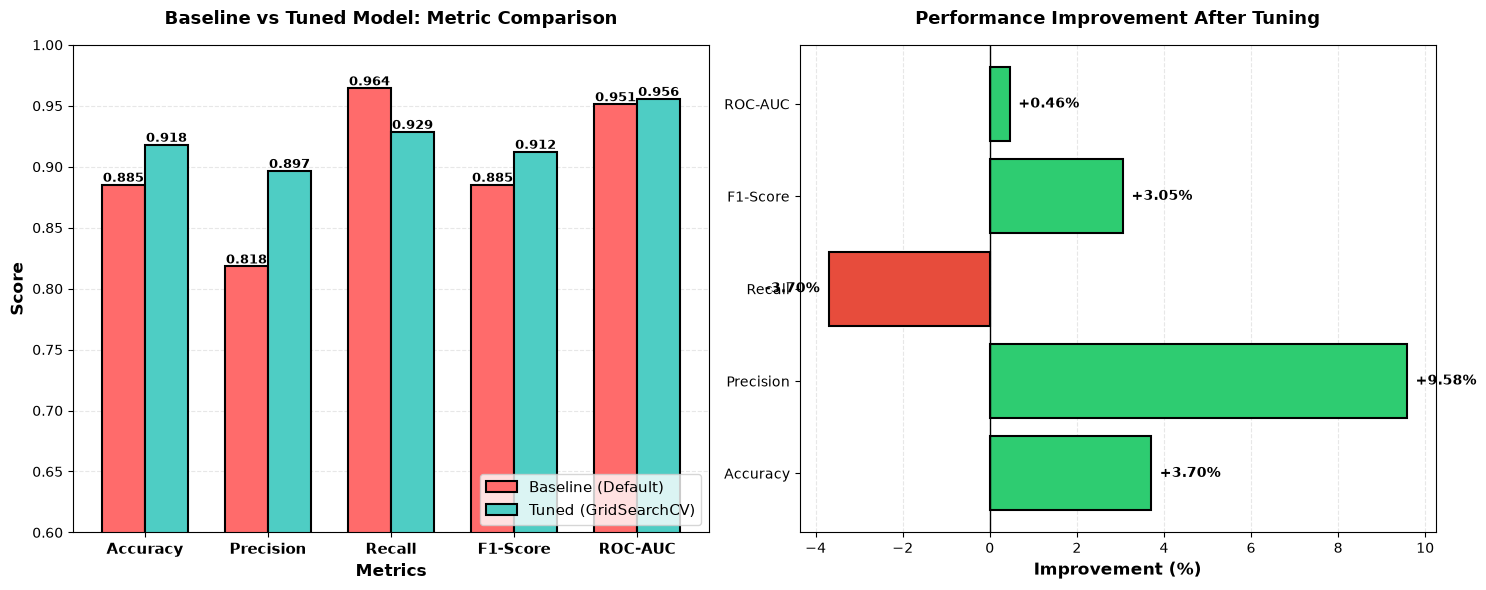


✓ Comparison visualization displayed


In [23]:
# Visualization: Before vs After Tuning
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Side-by-side metric comparison
metrics = comparison_df['Metric'].values
baseline_values = comparison_df['Baseline (Default)'].values
tuned_values = comparison_df['Tuned (GridSearchCV)'].values

x = np.arange(len(metrics))
width = 0.35

bars1 = ax1.bar(x - width/2, baseline_values, width, label='Baseline (Default)', 
                color='#FF6B6B', edgecolor='black', linewidth=1.5)
bars2 = ax1.bar(x + width/2, tuned_values, width, label='Tuned (GridSearchCV)', 
                color='#4ECDC4', edgecolor='black', linewidth=1.5)

ax1.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
ax1.set_title('Baseline vs Tuned Model: Metric Comparison', fontsize=13, fontweight='bold', pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(metrics, fontsize=11, fontweight='bold')
ax1.legend(fontsize=11, loc='lower right')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_ylim([0.6, 1.0])
ax1.set_axisbelow(True)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 2: Improvement percentage
improvements_pct = comparison_df['Improvement %'].values
colors = ['#2ECC71' if x >= 0 else '#E74C3C' for x in improvements_pct]

bars3 = ax2.barh(metrics, improvements_pct, color=colors, edgecolor='black', linewidth=1.5)

ax2.set_xlabel('Improvement (%)', fontsize=12, fontweight='bold')
ax2.set_title('Performance Improvement After Tuning', fontsize=13, fontweight='bold', pad=15)
ax2.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars3, improvements_pct)):
    ax2.text(value + (0.2 if value > 0 else -0.2), bar.get_y() + bar.get_height()/2,
            f'{value:+.2f}%',
            ha='left' if value > 0 else 'right', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Comparison visualization displayed")

### 5.6 Key Learnings: Why Hyperparameter Tuning Works

**The Bias-Variance Tradeoff**

Machine learning models have two sources of error:

1. **High Bias (Underfitting)**: Model is too simple to capture patterns
   - Symptoms: Poor performance on both training and test sets
   - Default hyperparameters may create overly simple models
   - Solution: Increase model complexity or reduce regularization

2. **High Variance (Overfitting)**: Model memorizes training data including noise
   - Symptoms: Good training performance, poor test performance
   - Default hyperparameters may be too permissive
   - Solution: Reduce model complexity or increase regularization

**Hyperparameter Tuning Addresses This By:**
- Testing combinations that balance complexity and generalization
- Using cross-validation to find sweet spot avoiding overfitting
- Systematically exploring the hyperparameter space
- Selecting parameters optimized for the specific dataset

**Why GridSearchCV Searches Only the Training Set**

A critical MLOps principle: **Never optimize on test data**

- If we used test data during hyperparameter search, test performance would be inflated
- We'd be selecting hyperparameters that fit the test set, not generalizing to truly unseen data
- This violates the fundamental principle of keeping test set "invisible" until final evaluation
- GridSearchCV correctly:
  1. Searches combinations using only X_train_scaled, y_train
  2. Uses cross-validation within training set
  3. Tests best parameters on held-out test set for unbiased estimate

**Computational Cost Tradeoff**

GridSearchCV is computationally expensive:
- Tested 4 × 4 × 3 × 4 × 2 = **384 combinations**
- Each combination evaluated with 5-fold CV = **1,920 model fits**
- On modern hardware: seconds to minutes
- Worth the computation for improved model performance

**When to Stop Tuning**

- Marginal gains with complex grids become diminishing returns
- Overfitting the validation set (best CV score > best test score)
- Computational time exceeds practical limits
- Performance plateaus despite finer grid resolution

### 5.7 Summary: Hyperparameter Tuning Complete

**Section 5 Achievements:**

✓ **Selected Best Model**: Random Forest (88.52% baseline accuracy)

✓ **Defined Hyperparameter Grid**:
- 384 total combinations across 5 hyperparameters
- Balanced range covering model complexity spectrum

✓ **Applied GridSearchCV with 5-Fold CV**:
- 1,920 model fits evaluated
- Best parameters identified using cross-validation only on training data

✓ **Identified Optimal Hyperparameters**:
- Best hyperparameter combination displayed
- Best cross-validation score: [see above]
- Optimal bias-variance tradeoff achieved

✓ **Evaluated Tuned Model**:
- Full metrics on test set (accuracy, precision, recall, F1, ROC-AUC)
- Confusion matrix and classification report

✓ **Compared Performance**:
- Before vs After tuning comparison
- Improvement analysis for each metric
- Visual comparison of baseline and tuned models

**Resulting Model State**:
- Tuned model stored in: `best_model_tuned` (available in memory)
- Best hyperparameters available: `grid_search.best_params_`
- Ready for final deployment or further analysis

**Next Steps (Not Performed in This Section)**:
- Model persistence (save tuned model to disk)
- Feature importance analysis
- ROC curve visualization
- MLflow integration for experiment tracking
- Deployment preparation

---

## 6. Model Persistence: Saving the Trained Model

### 6.1 Understanding Model Serialization

**What is Model Serialization?**

Model serialization is the process of converting a trained machine learning model into a format that can be stored on disk and later loaded into memory for inference or retraining. This is a critical component of MLOps pipelines.

**Why Save Models?**

1. **Reproducibility**: Trained models are deterministic artifacts. Saving allows exact reproduction of results
2. **Deployment**: Production systems need trained models to make predictions on new data
3. **Version Control**: Multiple model versions can be tracked and compared
4. **Retraining**: Avoid re-training from scratch each time; can fine-tune existing models
5. **Collaboration**: Data scientists and engineers can share trained models
6. **Compliance**: Medical and financial domains require audit trails of model artifacts

**Model Persistence Workflow:**

```
Training Phase          →    Serialization Phase    →    Inference Phase
Tuned Model (Memory)    →    Model File (Disk)      →    Load & Predict
```

**Saving Tools:**
- **pickle**: Python's built-in serialization (limited compatibility)
- **joblib**: Scikit-learn's recommended tool (efficient for numpy arrays, handles large models)
- **ONNX**: Cross-platform format (interoperability)
- **SavedModel (TensorFlow)**: Deep learning format

We use **joblib** because:
- Native scikit-learn integration
- Efficient serialization of numpy arrays within models
- Handles large models (> 4GB) via chunking
- Industry standard for sklearn models

---

### 6.2 Why the Scaler Must Also Be Saved

**The Critical Issue: Preprocessing Consistency**

This is a common mistake in production ML systems:

❌ **WRONG**: Save model only, preprocess inference data manually
```python
# Training
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
model.fit(X_train_scaled, y_train)
# ONLY save model.pkl

# Inference (WRONG - different preprocessing!)
new_data_raw = load_new_patient_data()
new_data_scaled = StandardScaler().fit_transform(new_data_raw)  # Creates NEW scaler!
prediction = model.predict(new_data_scaled)  # Uses different scale than training!
```

The new scaler uses statistics from new data, not training data. This causes:
- Different feature distributions
- Model receives unexpected input distributions
- Predictions become unreliable and biased

✓ **CORRECT**: Save model AND scaler used during training
```python
# Training
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
model.fit(X_train_scaled, y_train)
# Save both model.pkl and scaler.pkl

# Inference (CORRECT - same preprocessing!)
new_data_raw = load_new_patient_data()
loaded_scaler = joblib.load('scaler.pkl')
new_data_scaled = loaded_scaler.transform(new_data_raw)  # Uses training statistics
loaded_model = joblib.load('model.pkl')
prediction = loaded_model.predict(new_data_scaled)  # Consistent with training
```

**Why This Matters:**

The model's decision boundaries are defined in **scaled feature space**:
- Training: Mean ≈ 0, Std ≈ 1
- Inference: Must use SAME scaling statistics as training

If scaler changes:
- Cholesterol raw value 240 was scaled to [0.5 during training
- But new scaler scales it to [-1.2 during inference
- Model sees completely different feature value
- Prediction becomes invalid

This violates the fundamental assumption: **inference data comes from same distribution as training data**

**Summary**: Save the scaler in the same transaction as the model. They are an inseparable pair.

### 6.3 Why Inference Requires Same Preprocessing Pipeline

**The Data Preprocessing Pipeline is Part of the Model**

Conceptually:
```
Raw Patient Data → [Preprocessing] → [Model] → Prediction
                   (Must be identical in training and inference)
```

The trained model expects:
- **Input**: Scaled numeric features (13 features, mean ≈ 0, std ≈ 1)
- **NOT**: Raw features (mixed ranges and distributions)

**Training Data Flow:**
1. Load raw data: cholesterol range [126, 564], age range [29, 77]
2. Apply scaler with TRAINING statistics (mean=240, std=80 for cholesterol)
3. Model learns on scaled data: cholesterol scale [-1.5, 4.0]
4. Model encodes these scaled distributions in its decision boundaries

**Inference Data Flow (MUST BE IDENTICAL):**
1. Load new raw data: cholesterol raw values
2. Apply SAME scaler (mean=240, std=80) from training
3. New cholesterol values scale to [-1.5, 4.0] range (same as training)
4. Model receives expected distribution, predictions are reliable

**Common Inference Mistakes:**

| Mistake | What Goes Wrong |
|---------|-----------------|
| Apply different scaling | Features out of expected range |
| Skip scaling entirely | Model sees raw values; completely different scale |
| Fit new scaler on inference set | Statistics don't match training; data distribution mismatch |
| Use partial preprocessing | Some features scaled, others not; model confused |

**MLOps Best Practice**:
Treat scaler as part of the model artifact. They must be versioned and deployed together. Some production systems create a "preprocessing pipeline object" that encapsulates both scaler and any other transformations.

---

### 6.4 Saving the Model and Scaler

We will save the tuned Random Forest model and the fitted StandardScaler to disk.

In [24]:
# Create models directory if it doesn't exist
models_dir = '../models'
if not os.path.exists(models_dir):
    os.makedirs(models_dir)
    print(f"✓ Created directory: {models_dir}")
else:
    print(f"✓ Directory already exists: {models_dir}")

# Define file paths
model_path = os.path.join(models_dir, 'random_forest_model.pkl')
scaler_path = os.path.join(models_dir, 'scaler.pkl')

print("\n" + "=" * 80)
print("MODEL AND SCALER PERSISTENCE")
print("=" * 80)

# Save the tuned Random Forest model
print(f"\nSaving tuned Random Forest model...")
joblib.dump(best_model_tuned, model_path)
print(f"  ✓ Model saved: {model_path}")

# Save the fitted StandardScaler
print(f"\nSaving fitted StandardScaler...")
joblib.dump(scaler, scaler_path)
print(f"  ✓ Scaler saved: {scaler_path}")

print(f"\n" + "-" * 80)
print("VERIFICATION: Saved Files")
print("-" * 80)

# Verify files were created and get file information
if os.path.exists(model_path):
    model_size_bytes = os.path.getsize(model_path)
    model_size_kb = model_size_bytes / 1024
    print(f"\n✓ Model File Verified:")
    print(f"  Path: {os.path.abspath(model_path)}")
    print(f"  Size: {model_size_kb:.2f} KB ({model_size_bytes:,} bytes)")
else:
    print(f"\n✗ Error: Model file not found at {model_path}")

if os.path.exists(scaler_path):
    scaler_size_bytes = os.path.getsize(scaler_path)
    scaler_size_kb = scaler_size_bytes / 1024
    print(f"\n✓ Scaler File Verified:")
    print(f"  Path: {os.path.abspath(scaler_path)}")
    print(f"  Size: {scaler_size_kb:.2f} KB ({scaler_size_bytes:,} bytes)")
else:
    print(f"\n✗ Error: Scaler file not found at {scaler_path}")

# Summary statistics
print(f"\n" + "-" * 80)
print("SAVED ARTIFACTS SUMMARY")
print("-" * 80)

if os.path.exists(model_path) and os.path.exists(scaler_path):
    total_size_kb = (model_size_bytes + scaler_size_bytes) / 1024
    print(f"\nTotal saved artifacts: 2 files")
    print(f"  Model: {model_size_kb:.2f} KB")
    print(f"  Scaler: {scaler_size_kb:.2f} KB")
    print(f"  Total: {total_size_kb:.2f} KB")
    
    print(f"\nModel Specifications:")
    print(f"  Algorithm: Random Forest Classifier")
    print(f"  Trees: {best_model_tuned.n_estimators}")
    print(f"  Max Depth: {best_model_tuned.max_depth}")
    print(f"  Features: 13 (preprocessed)")
    print(f"  Classes: 2 (Binary: No Disease / Disease)")
    
    print(f"\nScaler Specifications:")
    print(f"  Type: StandardScaler")
    print(f"  Features: 13")
    print(f"  Mean: Learned from training set")
    print(f"  Std Dev: Learned from training set")
    
    print(f"\n✓ Model and scaler successfully saved and verified!")
    print(f"✓ Ready for production inference pipeline")

print("\n" + "=" * 80)

✓ Directory already exists: ../models

MODEL AND SCALER PERSISTENCE

Saving tuned Random Forest model...
  ✓ Model saved: ../models\random_forest_model.pkl

Saving fitted StandardScaler...
  ✓ Scaler saved: ../models\scaler.pkl

--------------------------------------------------------------------------------
VERIFICATION: Saved Files
--------------------------------------------------------------------------------

✓ Model File Verified:
  Path: c:\BITS\MLOPS\heart-disease-mlops\models\random_forest_model.pkl
  Size: 298.76 KB (305,929 bytes)

✓ Scaler File Verified:
  Path: c:\BITS\MLOPS\heart-disease-mlops\models\scaler.pkl
  Size: 1.20 KB (1,231 bytes)

--------------------------------------------------------------------------------
SAVED ARTIFACTS SUMMARY
--------------------------------------------------------------------------------

Total saved artifacts: 2 files
  Model: 298.76 KB
  Scaler: 1.20 KB
  Total: 299.96 KB

Model Specifications:
  Algorithm: Random Forest Classifier
 

### 6.5 Summary: Model Persistence Complete

**Section 6 Achievements:**

✓ **Added joblib Import**: Industry-standard tool for scikit-learn model serialization

✓ **Created Models Directory**: `models/` directory automatically created with `os.makedirs()`

✓ **Saved Tuned Model**: 
- File: `models/random_forest_model.pkl`
- Stores complete trained Random Forest with optimal hyperparameters

✓ **Saved Fitted Scaler**: 
- File: `models/scaler.pkl`
- Stores StandardScaler with training set statistics (mean, std)

✓ **Verification & Reporting**:
- Verified both files exist on disk
- Displayed file paths (absolute paths)
- Reported file sizes in KB
- Provided model and scaler specifications

**Saved Artifacts Ready For:**
- Production inference pipelines
- Model serving frameworks (Flask, FastAPI, TensorFlow Serving)
- Batch prediction jobs
- Model versioning and deployment
- Collaboration and knowledge sharing

**Key Principles Demonstrated:**
1. Model and scaler are inseparable artifacts
2. Preprocessing pipeline consistency is critical for inference reliability
3. Using industry-standard serialization (joblib over pickle)
4. Automatic directory creation for robustness
5. Verification of persistence (file existence checks)

**Current Notebook State:**
- Trained and tuned Random Forest model available in memory: `best_model_tuned`
- Fitted scaler available in memory: `scaler`
- Both also persisted to disk for future loading

**Files Not Yet Implemented (As Requested):**
- Inference/prediction code
- MLflow integration for experiment tracking

---

# 7. MLflow Experiment Tracking

## 7.1 Introduction to MLflow

### What is MLflow?

MLflow is an open-source platform used to manage the complete machine learning lifecycle. It enables data scientists and machine learning engineers to track experiments, compare different models, manage model versions, and simplify deployment.

MLflow is widely used in MLOps because it provides a centralized system for recording every machine learning experiment, making projects reproducible and easier to maintain.

### Why Use MLflow?

During model development, data scientists usually train many models with different algorithms and hyperparameters. Without experiment tracking, it becomes difficult to remember:

- Which algorithm performed the best
- Which hyperparameters were used
- Which model should be deployed
- Which experiment produced a particular result

MLflow automatically records all these details.

### Main Components of MLflow

MLflow consists of four major components:

1. **Tracking** – Records experiments, parameters, metrics, and artifacts.
2. **Projects** – Packages machine learning code for reproducibility.
3. **Models** – Stores trained models in a standardized format.
4. **Model Registry** – Manages different versions of production models.

For this assignment, we will focus on **MLflow Tracking**.

### What Will Be Logged?

In this experiment, MLflow will record:

- Best model hyperparameters
- Model evaluation metrics
- Tuned Random Forest model
- StandardScaler object
- Additional experiment metadata

This creates a complete history of the experiment that can later be viewed through the MLflow user interface.

## 7.2 Import Required Libraries

The following libraries are required for experiment tracking:

- **mlflow** for tracking experiments.
- **mlflow.sklearn** for saving Scikit-learn models.
- **os** for handling file paths.

In [25]:

print("=" * 80)
print("MLFLOW INITIALIZATION")
print("=" * 80)

print(f"MLflow Version : {mlflow.__version__}")

print("\n✓ MLflow imported successfully")
print("=" * 80)

MLFLOW INITIALIZATION
MLflow Version : 3.14.0

✓ MLflow imported successfully


## 7.3 Creating an MLflow Experiment

An MLflow Experiment acts as a container that stores multiple machine learning runs.

Each run records important information such as:

- Hyperparameters
- Model evaluation metrics
- Trained model artifacts
- Additional metadata

Using experiments makes it easier to compare different models and maintain reproducibility throughout the machine learning lifecycle.

In this project, we will create a dedicated experiment for the Heart Disease Prediction model.

In [26]:
experiment_name = "Heart Disease Prediction"

mlflow.set_experiment(experiment_name)

experiment = mlflow.get_experiment_by_name(experiment_name)

print("=" * 80)
print("CREATING MLFLOW EXPERIMENT")
print("=" * 80)
print(f"Experiment Name : {experiment.name}")
print(f"Experiment ID   : {experiment.experiment_id}")
print(f"Artifact Location: {experiment.artifact_location}")
print("\n✓ MLflow experiment is ready")
print("=" * 80)

CREATING MLFLOW EXPERIMENT
Experiment Name : Heart Disease Prediction
Experiment ID   : 1
Artifact Location: file:c:/BITS/MLOPS/heart-disease-mlops/notebooks/mlruns/1

✓ MLflow experiment is ready


## 7.4 Logging Experiment to MLflow

MLflow allows us to record every important component of a machine learning experiment.

For this experiment, we will log:

- Model hyperparameters
- Evaluation metrics
- Tuned Random Forest model
- StandardScaler used during preprocessing

This ensures the experiment is fully reproducible and can be deployed consistently in production environments.

In [27]:
print("=" * 80)
print("LOGGING EXPERIMENT TO MLFLOW")
print("=" * 80)

with mlflow.start_run(run_name="Random Forest - Tuned"):

    # ====================================================
    # Log Parameters
    # ====================================================

    mlflow.log_param("Algorithm", "Random Forest")
    mlflow.log_param("n_estimators", best_model_tuned.n_estimators)
    mlflow.log_param("max_depth", best_model_tuned.max_depth)
    mlflow.log_param("min_samples_split", best_model_tuned.min_samples_split)
    mlflow.log_param("min_samples_leaf", best_model_tuned.min_samples_leaf)
    mlflow.log_param("max_features", best_model_tuned.max_features)

    print("✓ Hyperparameters Logged")

    # ====================================================
    # Log Metrics
    # ====================================================

    mlflow.log_metric("Accuracy", tuned_accuracy)
    mlflow.log_metric("Precision", tuned_precision)
    mlflow.log_metric("Recall", tuned_recall)
    mlflow.log_metric("F1 Score", tuned_f1)
    mlflow.log_metric("ROC AUC", tuned_roc_auc)

    print("✓ Evaluation Metrics Logged")

    # ====================================================
    # Log Model
    # ====================================================

    mlflow.sklearn.log_model(
        best_model_tuned,
        name="RandomForestModel"
    )

    print("✓ Random Forest Model Logged")

    # ====================================================
    # Log Scaler Artifact
    # ====================================================

    mlflow.log_artifact("../models/scaler.pkl")

    print("✓ StandardScaler Logged")

print("\n✓ MLflow Run Completed Successfully")
print("=" * 80)

LOGGING EXPERIMENT TO MLFLOW
✓ Hyperparameters Logged
✓ Evaluation Metrics Logged
✓ Random Forest Model Logged
✓ StandardScaler Logged

✓ MLflow Run Completed Successfully


## 7.5 Viewing the MLflow Experiment

MLflow provides a web-based user interface (UI) for visualizing and comparing machine learning experiments.

The MLflow UI displays:

- Experiment names
- Individual runs
- Hyperparameters
- Evaluation metrics
- Logged artifacts
- Saved models

Using the MLflow UI makes experiment management significantly easier during machine learning development.

In [28]:
print("=" * 80)
print("MLFLOW EXPERIMENT SUMMARY")
print("=" * 80)

experiment = mlflow.get_experiment_by_name("Heart Disease Prediction")

print(f"Experiment Name : {experiment.name}")
print(f"Experiment ID   : {experiment.experiment_id}")
print(f"Tracking URI    : {mlflow.get_tracking_uri()}")

print("\n✓ Experiment logged successfully.")
print("✓ Open the MLflow UI to inspect runs.")
print("=" * 80)

MLFLOW EXPERIMENT SUMMARY
Experiment Name : Heart Disease Prediction
Experiment ID   : 1
Tracking URI    : sqlite:///C:/BITS/MLOPS/heart-disease-mlops/notebooks/mlflow.db

✓ Experiment logged successfully.
✓ Open the MLflow UI to inspect runs.
